In [32]:
import pandas as pd
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1️⃣ Load the dataset
file_path = r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv"
df = pd.read_csv(file_path)

# 2️⃣ Clean column names (remove special characters and spaces)
df.columns = df.columns.str.replace(r'[\[\]° ]', '', regex=True)  # Remove '[', ']', '°', and spaces
print("Cleaned Column Names:", df.columns.tolist())

# 3️⃣ Add label (0 for walking, since we only have walking data for now)
df["label"] = 0  # All data is labeled as walking (0)

# 4️⃣ Drop unnecessary columns (time and temperature)
X = df.drop(columns=["label", "Times", "stts22h_tempC"])  # Use cleaned column names
y = df["label"]

# 5️⃣ Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 6️⃣ Define LightGBM model (binary classification)
model = lgb.LGBMClassifier(
    objective="binary",  # Binary classification (walking vs. not walking)
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    n_estimators=1000,
    random_state=42
)

# 7️⃣ Train the model with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="binary_logloss",  # Binary log loss for binary classification
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 8️⃣ Make predictions
y_pred = model.predict(X_val)

# 9️⃣ Evaluate accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {accuracy:.4f}")

# 🔟 Classification report and confusion matrix
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# 1️⃣1️⃣ Feature importance
try:
    # Plot feature importance
    lgb.plot_importance(model, importance_type='gain', max_num_features=10)  # Use 'gain' or 'split'
    plt.title("Feature Importance (LightGBM)")
    plt.show()
except Exception as e:
    print(f"Error plotting feature importance: {e}")
    print("Ensure the model was trained successfully and features are valid.")

# 1️⃣2️⃣ Debugging: Print feature importance values
importance = model.feature_importances_
feature_names = model.feature_name_
print("\nFeature Importance Values:")
for feature, importance_value in zip(feature_names, importance):
    print(f"{feature}: {importance_value}")

Cleaned Column Names: ['Times', 'lsm6dsv16x_acc_xg', 'lsm6dsv16x_acc_yg', 'lsm6dsv16x_acc_zg', 'lsm6dsv16x_gyro_xdps', 'lsm6dsv16x_gyro_ydps', 'lsm6dsv16x_gyro_zdps', 'lis2du12_acc_xg', 'lis2du12_acc_yg', 'lis2du12_acc_zg', 'lis2mdl_mag_xG', 'lis2mdl_mag_yG', 'lis2mdl_mag_zG', 'lps22df_presshPa', 'stts22h_tempC']
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 838860
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066571 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3069
[LightGBM] [Info] Number of data points in the train set: 838860, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000000 -> initscore=-34.538776
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
Training until validation scores don't imp

In [5]:
pip install lightgbm pandas scikit-learn numpy


Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install --upgrade lightgbm


In [ ]:
"C:\Users\Ashmeet\OneDrive\Documents\500Running.csv"
"C:\Users\Ashmeet\OneDrive\Documents\falling1.csv"
"C:\Users\Ashmeet\OneDrive\Documents\falling2.csv"
"C:\Users\Ashmeet\OneDrive\Documents\falling3.csv"
"C:\Users\Ashmeet\OneDrive\Documents\falling4.csv"
"C:\Users\Ashmeet\OneDrive\Documents\11min.csv"

In [5]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load and preprocess data
file_paths = {
    'walking': r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv",
    'running': r"C:\Users\Ashmeet\OneDrive\Documents\500Running.csv",
    'falling_while_running': r"C:\Users\Ashmeet\OneDrive\Documents\falling1.csv",
    'falling_while_walking': r"C:\Users\Ashmeet\OneDrive\Documents\falling3.csv",
}

dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label  # Assign activity label
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True).dropna()

# Features and target selection
features = [
    'lsm6dsv16x_acc_x [g]', 'lsm6dsv16x_acc_y [g]', 'lsm6dsv16x_acc_z [g]',
    'lsm6dsv16x_gyro_x [dps]', 'lsm6dsv16x_gyro_y [dps]', 'lsm6dsv16x_gyro_z [dps]',
    'lis2du12_acc_x [g]', 'lis2du12_acc_y [g]', 'lis2du12_acc_z [g]',
    'lis2mdl_mag_x [G]', 'lis2mdl_mag_y [G]', 'lis2mdl_mag_z [G]',
    'lps22df_press [hPa]', 'mp23db01hp_mic [Waveform]', 'stts22h_temp [°C]'
]

X = data[features].values
y = data['label'].values

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Normalize data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape for CNN input (samples, time steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Select only 20% of the data for training
train_size = int(0.02 * len(X))  # 20% of total dataset
indices = np.random.choice(len(X), train_size, replace=False)  # Randomly select indices

X_train = X[indices]
y_train = y[indices]

# Build CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(y)), activation='softmax')  # Output layer for multi-class classification
])

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model only on 20% of data
model.fit(X_train, y_train, epochs=20, batch_size=32)

# Save trained model
model.save("cnn_activity_recognition_20percent.h5")


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load and merge datasets
file_paths = {
    'walking': r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv",
    'running': r"C:\Users\Ashmeet\OneDrive\Documents\500Running.csv",
    'falling_while_running': r"C:\Users\Ashmeet\OneDrive\Documents\falling1.csv",
    'falling_while_walking': r"C:\Users\Ashmeet\OneDrive\Documents\falling3.csv",
}


dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label  # Assign activity label
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

# Check for missing values
data = data.dropna()

# Extract features and target column
features = [
    'lsm6dsv16x_acc_x [g]', 'lsm6dsv16x_acc_y [g]', 'lsm6dsv16x_acc_z [g]',
    'lsm6dsv16x_gyro_x [dps]', 'lsm6dsv16x_gyro_y [dps]', 'lsm6dsv16x_gyro_z [dps]',
    'lis2du12_acc_x [g]', 'lis2du12_acc_y [g]', 'lis2du12_acc_z [g]',
    'lis2mdl_mag_x [G]', 'lis2mdl_mag_y [G]', 'lis2mdl_mag_z [G]',
    'lps22df_press [hPa]', 'mp23db01hp_mic [Waveform]', 'stts22h_temp [°C]'
]
X = data[features]
y = data['label']

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define Optuna objective function for tuning LightGBM
def objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': len(np.unique(y)),
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 50),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 5),
        'max_bin': trial.suggest_int('max_bin', 255, 512),
        'num_boost_round': trial.suggest_int('num_boost_round', 100, 1000),
    }
    
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    val_scores = []
    
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        train_data = lgb.Dataset(X_tr, label=y_tr)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
        
        model = lgb.train(params, train_data, valid_sets=[val_data], callbacks=[lgb.early_stopping(50)])
        
        y_pred = np.argmax(model.predict(X_val), axis=1)
        val_scores.append(accuracy_score(y_val, y_pred))
    
    return np.mean(val_scores)

# Run Optuna for hyperparameter tuning
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# Train the best model with optimized hyperparameters
best_params = study.best_params
best_params['objective'] = 'multiclass'
best_params['num_class'] = len(np.unique(y))
best_params['metric'] = 'multi_logloss'

train_data = lgb.Dataset(X_train, label=y_train)
model = lgb.train(best_params, train_data)

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


[I 2025-02-21 17:46:55,698] A new study created in memory with name: no-name-09f2f7ee-d8ab-404f-88e3-e5e18639b67e


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064806 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5518
[LightGBM] [Info] Number of data points in the train set: 998766, number of used features: 15
[LightGBM] [Info] Start training from score -1.747011
[LightGBM] [Info] Start training from score -1.872175
[LightGBM] [Info] Start training from score -0.397620
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

[W 2025-02-21 17:47:55,993] Trial 0 failed with parameters: {'learning_rate': 0.06406700735799477, 'num_leaves': 22, 'max_depth': 11, 'min_data_in_leaf': 42, 'feature_fraction': 0.5134980426066947, 'bagging_fraction': 0.7793624515308595, 'bagging_freq': 2, 'max_bin': 415, 'num_boost_round': 408} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\Ashmeet\anaconda3\lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "<ipython-input-3-0c2307e5b099>", line 80, in objective
    model = lgb.train(params, train_data, valid_sets=[val_data], callbacks=[lgb.early_stopping(50)])
  File "C:\Users\Ashmeet\anaconda3\lib\site-packages\lightgbm\engine.py", line 322, in train
    booster.update(fobj=fobj)
  File "C:\Users\Ashmeet\anaconda3\lib\site-packages\lightgbm\basic.py", line 4155, in update
    _LIB.LGBM_BoosterUpdateOneIter(
KeyboardInterrupt
[W 2025-02-21 17:47:56,002] Trial 0 faile

KeyboardInterrupt: 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py

# import lightgbm as lgb
# import optuna
# from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load and merge datasets
file_paths = {
    'walking': r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv",
    'running': r"C:\Users\Ashmeet\OneDrive\Documents\500Running.csv",
    'falling_while_running': r"C:\Users\Ashmeet\OneDrive\Documents\falling1.csv",
    'falling_while_walking': r"C:\Users\Ashmeet\OneDrive\Documents\falling3.csv",
}
dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label  # Assign activity label
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

# Check for missing values
data = data.dropna()

print(data.columns)

Index(['Time [s]', 'lsm6dsv16x_acc_x [g]', 'lsm6dsv16x_acc_y [g]',
       'lsm6dsv16x_acc_z [g]', 'lsm6dsv16x_gyro_x [dps]',
       'lsm6dsv16x_gyro_y [dps]', 'lsm6dsv16x_gyro_z [dps]',
       'lis2du12_acc_x [g]', 'lis2du12_acc_y [g]', 'lis2du12_acc_z [g]',
       'lis2mdl_mag_x [G]', 'lis2mdl_mag_y [G]', 'lis2mdl_mag_z [G]',
       'lps22df_press [hPa]', 'stts22h_temp [°C]', 'label',
       'mp23db01hp_mic [Waveform]'],
      dtype='object')


Index(['Time [s]', 'lsm6dsv16x_acc_x [g]', 'lsm6dsv16x_acc_y [g]',
       'lsm6dsv16x_acc_z [g]', 'lsm6dsv16x_gyro_x [dps]',
       'lsm6dsv16x_gyro_y [dps]', 'lsm6dsv16x_gyro_z [dps]',
       'lis2du12_acc_x [g]', 'lis2du12_acc_y [g]', 'lis2du12_acc_z [g]',
       'lis2mdl_mag_x [G]', 'lis2mdl_mag_y [G]', 'lis2mdl_mag_z [G]',
       'lps22df_press [hPa]', 'stts22h_temp [°C]', 'label'],
      dtype='object')


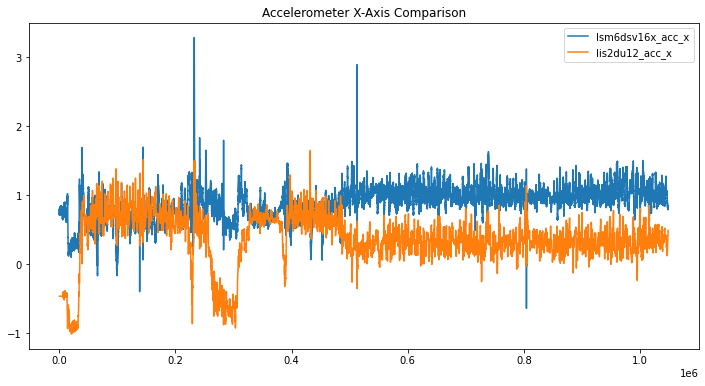

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import lightgbm as lgb
# import optuna
# from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load and merge datasets
file_paths = {
    'walking': r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv",
}
dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label  # Assign activity label
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

print(data.columns)
# Check for missing values
data = data.dropna()
plt.figure(figsize=(12, 6))
plt.plot(data['lsm6dsv16x_acc_x [g]'], label='lsm6dsv16x_acc_x')
plt.plot(data['lis2du12_acc_x [g]'], label='lis2du12_acc_x')
plt.title('Accelerometer X-Axis Comparison')
plt.legend()
plt.show()


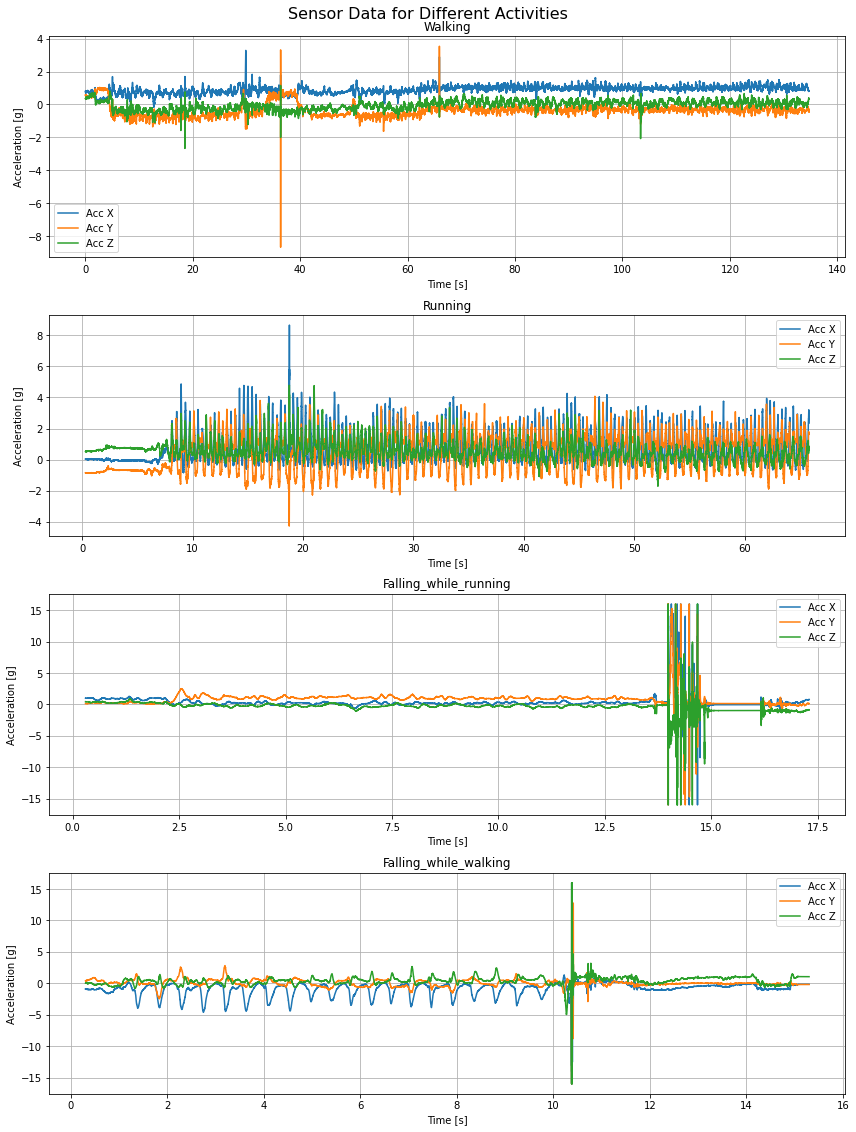

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths
file_paths = {
    'walking': r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv",
    'running': r"C:\Users\Ashmeet\OneDrive\Documents\500Running.csv",
    'falling_while_running': r"C:\Users\Ashmeet\OneDrive\Documents\falling1.csv",
    'falling_while_walking': r"C:\Users\Ashmeet\OneDrive\Documents\falling3.csv",
}

# Create a figure with 4 subplots (one for each file)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 16))
fig.suptitle('Sensor Data for Different Activities', fontsize=16)

# Loop through each file and plot the data
for i, (label, path) in enumerate(file_paths.items()):
    # Read the CSV file
    df = pd.read_csv(path)
    
    # Plot accelerometer data
    axes[i].plot(df['Time [s]'], df['lsm6dsv16x_acc_x [g]'], label='Acc X')
    axes[i].plot(df['Time [s]'], df['lsm6dsv16x_acc_y [g]'], label='Acc Y')
    axes[i].plot(df['Time [s]'], df['lsm6dsv16x_acc_z [g]'], label='Acc Z')
    
    # Set subplot title and labels
    axes[i].set_title(label.capitalize())
    axes[i].set_xlabel('Time [s]')
    axes[i].set_ylabel('Acceleration [g]')
    axes[i].legend()
    axes[i].grid(True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# File paths
file_paths = {
    'walking': r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv",
    'running': r"C:\Users\Ashmeet\OneDrive\Documents\500Running.csv",
    'falling_while_running': r"C:\Users\Ashmeet\OneDrive\Documents\falling1.csv",
    'falling_while_walking': r"C:\Users\Ashmeet\OneDrive\Documents\falling3.csv",
}

# Load and combine data
dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label  # Add activity label
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

print(data.head())  # First few rows
print(data.info())  # Column names and data types
print(data['label'].value_counts())  # Distribution of labels

data = data.dropna()  # Drop rows with missing values

from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])

# Check the mapping
print(label_encoder.classes_)  # Shows the mapping of labels to numbers

from sklearn.preprocessing import StandardScaler

# Separate features (X) and labels (y)
X = data.drop(columns=['label', 'Time [s]', 'mp23db01hp_mic [Waveform]'])  # Drop non-sensor columns
y = data['label']

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

import numpy as np

# Example: Add mean and standard deviation as new features
X['acc_x_mean'] = X['lsm6dsv16x_acc_x [g]'].rolling(window=10).mean()
X['acc_x_std'] = X['lsm6dsv16x_acc_x [g]'].rolling(window=10).std()

from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
}

# Perform Grid Search
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

# Train the model with the best parameters
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

from xgboost import XGBClassifier

# Train XGBoost model
model = XGBClassifier()
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [1]:
# Step 1: Load and Preprocess the Data
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# File paths
file_paths = {
    'walking': r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv",
    'running': r"C:\Users\Ashmeet\OneDrive\Documents\500Running.csv",
    'falling_while_running': r"C:\Users\Ashmeet\OneDrive\Documents\falling1.csv",
    'falling_while_walking': r"C:\Users\Ashmeet\OneDrive\Documents\falling3.csv",
}

# Load and combine data
dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label  # Add activity label
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

# Check the data
print(data.head())
print(data.info())
print(data['label'].value_counts())

# Handle missing values
data = data.dropna()

# Encode labels
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
print("Label Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Separate features (X) and labels (y)
X = data.drop(columns=['label', 'Time [s]', 'mp23db01hp_mic [Waveform]'])  # Drop non-sensor columns
y = data['label']

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Split the Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 3: Train a Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 4: Evaluate the Model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Step 5: Save the Model
joblib.dump(model, 'activity_classifier.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved successfully!")

   Time [s]  lsm6dsv16x_acc_x [g]  lsm6dsv16x_acc_y [g]  lsm6dsv16x_acc_z [g]  \
0  0.067913              0.798368              0.580232              0.352824   
1  0.068029              0.797880              0.578768              0.344528   
2  0.068146              0.797880              0.579256              0.342576   
3  0.068262              0.800808              0.584136              0.348920   
4  0.068378              0.801296              0.585112              0.342088   

   lsm6dsv16x_gyro_x [dps]  lsm6dsv16x_gyro_y [dps]  lsm6dsv16x_gyro_z [dps]  \
0               -25.480000                   -11.62                   -12.18   
1               -25.620001                   -11.62                   -12.18   
2               -25.620001                   -11.62                   -12.18   
3               -25.760000                   -11.62                   -12.18   
4               -25.760000                   -11.48                   -12.32   

   lis2du12_acc_x [g]  lis2du12_

In [23]:
import pandas as pd
import joblib

# Load the model, label encoder, and scaler
model = joblib.load('activity_classifier.pkl')
label_encoder = joblib.load('label_encoder.pkl')
scaler = joblib.load('scaler.pkl')

# Load new sensor data
file_paths = {
    'predict': r"C:\Users\Ashmeet\OneDrive\Documents\falling2.csv",
}
dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label  # Assign activity label (not needed for prediction)
    dataframes.append(df)

new_data = pd.concat(dataframes, ignore_index=True)

# Drop unnecessary columns (same as during training)
# Conditionally drop 'mp23db01hp_mic [Waveform]' if it exists
if 'mp23db01hp_mic [Waveform]' in new_data.columns:
    new_data = new_data.drop(columns=['mp23db01hp_mic [Waveform]'])

# Drop other unnecessary columns
new_data = new_data.drop(columns=['Time [s]', 'label'])

# Check for missing values
new_data = new_data.dropna()

# Normalize the new data using the same scaler
new_data_scaled = scaler.transform(new_data)

# Make predictions
predictions = model.predict(new_data_scaled)
print("Predicted Activities:", label_encoder.inverse_transform(predictions))

Predicted Activities: ['falling_while_walking' 'falling_while_walking' 'falling_while_walking'
 ... 'falling_while_walking' 'falling_while_walking'
 'falling_while_walking']


Here’s a concise version of the extra features for your smartwatch using accelerometer, gyroscope, temperature, and timestamp data:

1. **Activity Intensity:** Measure walking/running effort and estimate calories burned.
2. **Posture Detection:** Identify standing, sitting, or lying down positions.
3. **Sleep Monitoring:** Track sleep patterns using motion and wrist temp.
4. **Fall Impact:** Assess fall severity with acceleration peaks.
5. **Gesture Controls:** Recognize wrist flicks/twists for hands-free use.
6. **Environment Detection:** Infer indoors/outdoors or stairs with motion and temp.
7. **Fatigue/Stress:** Spot slower or erratic movements for health insights.
8. **Step Cadence:** Count steps and analyze walking/running rhythm.
9. **Temp Alerts:** Warn about fever or extreme exposure.
10. **Trends:** Show activity/temp history over time.



Step Counting: Track steps using accelerometer peaks, refined by gyroscope.
Step Cadence: Analyze walking/running rhythm with step frequency.
Activity Intensity: Measure effort levels and estimate calories.
Posture Detection: Detect standing, sitting, or lying down.
Sleep Monitoring: Track sleep with motion and temp changes.
Fall Impact: Gauge fall severity via acceleration spikes.
Gesture Controls: Use wrist flicks/twists for commands.
Environment Detection: Spot stairs or indoors/outdoors with motion/temp.
Fatigue/Stress: Identify slow or shaky movements.
Temp Alerts: Warn of fever or extreme conditions.
Trends: Show activity/step/temp history.

Focus on your audience’s needs (fitness, health, etc.) to pick the best ones!

Cleaned Column Names: ['Times', 'lsm6dsv16x_acc_xg', 'lsm6dsv16x_acc_yg', 'lsm6dsv16x_acc_zg', 'lsm6dsv16x_gyro_xdps', 'lsm6dsv16x_gyro_ydps', 'lsm6dsv16x_gyro_zdps', 'lis2du12_acc_xg', 'lis2du12_acc_yg', 'lis2du12_acc_zg', 'lis2mdl_mag_xG', 'lis2mdl_mag_yG', 'lis2mdl_mag_zG', 'lps22df_presshPa', 'stts22h_tempC']


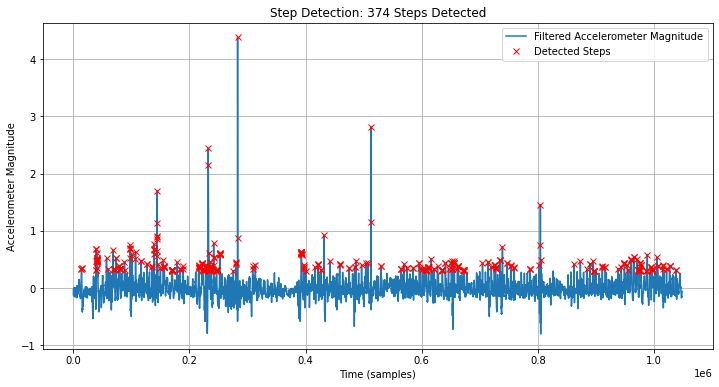

Number of steps detected: 374


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# 1️⃣ Load the dataset
file_path = r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv"
df = pd.read_csv(file_path)

# 2️⃣ Clean column names (remove special characters and spaces)
df.columns = df.columns.str.replace(r'[\[\]° ]', '', regex=True)  # Remove '[', ']', '°', and spaces
print("Cleaned Column Names:", df.columns.tolist())

# 3️⃣ Use accelerometer data (e.g., lsm6dsv16x_acc_x, lsm6dsv16x_acc_y, lsm6dsv16x_acc_z)
acc_x = df['lsm6dsv16x_acc_xg'].values
acc_y = df['lsm6dsv16x_acc_yg'].values
acc_z = df['lsm6dsv16x_acc_zg'].values

# 4️⃣ Calculate the magnitude of the accelerometer signal
acc_magnitude = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)

# 5️⃣ Subtract gravity (approximate mean to remove the static component)
acc_magnitude = acc_magnitude - np.mean(acc_magnitude)

# 6️⃣ Apply a low-pass filter to remove high-frequency noise
def low_pass_filter(data, cutoff_freq, sample_rate, order=4):
    nyquist_freq = 0.5 * sample_rate
    normal_cutoff = cutoff_freq / nyquist_freq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

sample_rate = 50  # Assuming 50 Hz sampling rate (adjust based on your data)
cutoff_freq = 2.0  # Cutoff frequency for step detection (2 Hz is typical for walking/running)
acc_magnitude_filtered = low_pass_filter(acc_magnitude, cutoff_freq, sample_rate)

# 7️⃣ Find peaks in the filtered accelerometer magnitude signal
peaks, _ = find_peaks(acc_magnitude_filtered, height=0.3, distance=25)  # Adjusted height and distance
num_steps = len(peaks)

# 8️⃣ Plot the accelerometer magnitude and detected peaks
plt.figure(figsize=(12, 6))
plt.plot(acc_magnitude_filtered, label='Filtered Accelerometer Magnitude')
plt.plot(peaks, acc_magnitude_filtered[peaks], "x", label='Detected Steps', color='red')
plt.title(f"Step Detection: {num_steps} Steps Detected")
plt.xlabel("Time (samples)")
plt.ylabel("Accelerometer Magnitude")
plt.legend()
plt.grid()
plt.show()

print(f"Number of steps detected: {num_steps}")

Cleaned Column Names: ['Times', 'lsm6dsv16x_acc_xg', 'lsm6dsv16x_acc_yg', 'lsm6dsv16x_acc_zg', 'lsm6dsv16x_gyro_xdps', 'lsm6dsv16x_gyro_ydps', 'lsm6dsv16x_gyro_zdps', 'lis2du12_acc_xg', 'lis2du12_acc_yg', 'lis2du12_acc_zg', 'lis2mdl_mag_xG', 'lis2mdl_mag_yG', 'lis2mdl_mag_zG', 'lps22df_presshPa', 'stts22h_tempC']
Your speed is 0.05 km/h. You should walk faster to reach the target speed of 5.0 km/h.


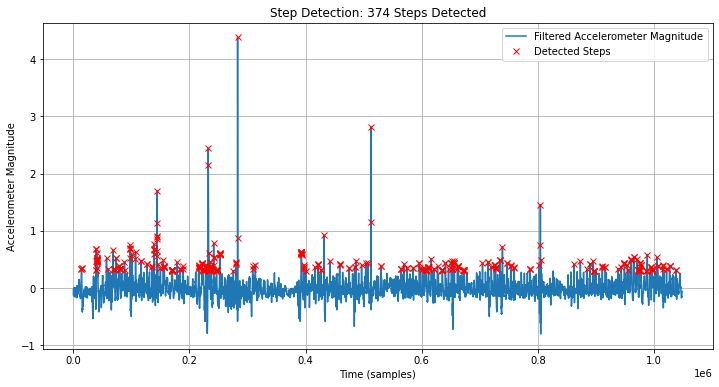

Number of steps detected: 374
Total time: 20971.50 seconds
Speed: 0.05 km/h


In [20]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks, butter, filtfilt

# 1️⃣ Load the dataset
file_path = r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv"
df = pd.read_csv(file_path)

# 2️⃣ Clean column names (remove special characters and spaces)
df.columns = df.columns.str.replace(r'[\[\]° ]', '', regex=True)  # Remove '[', ']', '°', and spaces
print("Cleaned Column Names:", df.columns.tolist())

# 3️⃣ Use accelerometer data (e.g., lsm6dsv16x_acc_x, lsm6dsv16x_acc_y, lsm6dsv16x_acc_z)
acc_x = df['lsm6dsv16x_acc_xg'].values
acc_y = df['lsm6dsv16x_acc_yg'].values
acc_z = df['lsm6dsv16x_acc_zg'].values

# 4️⃣ Calculate the magnitude of the accelerometer signal
acc_magnitude = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)

# 5️⃣ Subtract gravity (approximate mean to remove the static component)
acc_magnitude = acc_magnitude - np.mean(acc_magnitude)

# 6️⃣ Apply a low-pass filter to remove high-frequency noise
def low_pass_filter(data, cutoff_freq, sample_rate, order=4):
    nyquist_freq = 0.5 * sample_rate
    normal_cutoff = cutoff_freq / nyquist_freq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

sample_rate = 50  # Assuming 50 Hz sampling rate (adjust based on your data)
cutoff_freq = 2.0  # Cutoff frequency for step detection (2 Hz is typical for walking/running)
acc_magnitude_filtered = low_pass_filter(acc_magnitude, cutoff_freq, sample_rate)

# 7️⃣ Find peaks in the filtered accelerometer magnitude signal
peaks, _ = find_peaks(acc_magnitude_filtered, height=0.3, distance=25)  # Adjusted height and distance
num_steps = len(peaks)

# 8️⃣ Calculate speed
step_length = 0.75  # Average step length in meters (adjust based on user input)
total_time = len(acc_magnitude) / sample_rate  # Total time in seconds
speed_mps = (num_steps * step_length) / total_time  # Speed in meters per second
speed_kmph = speed_mps * 3.6  # Speed in kilometers per hour

# 9️⃣ Provide feedback to the user
target_speed_kmph = 5.0  # Target speed for brisk walking (adjust as needed)
if speed_kmph < target_speed_kmph:
    print(f"Your speed is {speed_kmph:.2f} km/h. You should walk faster to reach the target speed of {target_speed_kmph} km/h.")
else:
    print(f"Great job! Your speed is {speed_kmph:.2f} km/h, which meets the target speed of {target_speed_kmph} km/h.")

# 🔟 Plot the accelerometer magnitude and detected peaks
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(acc_magnitude_filtered, label='Filtered Accelerometer Magnitude')
plt.plot(peaks, acc_magnitude_filtered[peaks], "x", label='Detected Steps', color='red')
plt.title(f"Step Detection: {num_steps} Steps Detected")
plt.xlabel("Time (samples)")
plt.ylabel("Accelerometer Magnitude")
plt.legend()
plt.grid()
plt.show()

print(f"Number of steps detected: {num_steps}")
print(f"Total time: {total_time:.2f} seconds")
print(f"Speed: {speed_kmph:.2f} km/h")

Cleaned Column Names: ['Times', 'lsm6dsv16x_acc_xg', 'lsm6dsv16x_acc_yg', 'lsm6dsv16x_acc_zg', 'lsm6dsv16x_gyro_xdps', 'lsm6dsv16x_gyro_ydps', 'lsm6dsv16x_gyro_zdps', 'lis2du12_acc_xg', 'lis2du12_acc_yg', 'lis2du12_acc_zg', 'lis2mdl_mag_xG', 'lis2mdl_mag_yG', 'lis2mdl_mag_zG', 'lps22df_presshPa', 'stts22h_tempC']
Your speed is 0.05 km/h. You should walk faster to reach the target speed of 5.0 km/h.


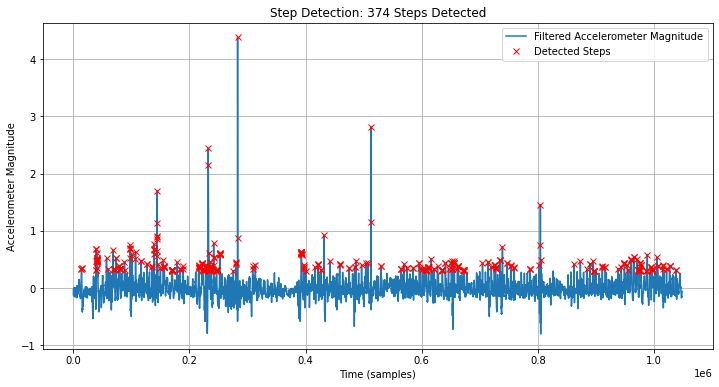

Number of steps detected: 374
Total time: 20971.50 seconds
Speed: 0.05 km/h


In [21]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks, butter, filtfilt

# 1️⃣ Load the dataset
file_path = r"C:\Users\Ashmeet\OneDrive\Documents\11min.csv"
df = pd.read_csv(file_path)

# 2️⃣ Clean column names (remove special characters and spaces)
df.columns = df.columns.str.replace(r'[\[\]° ]', '', regex=True)  # Remove '[', ']', '°', and spaces
print("Cleaned Column Names:", df.columns.tolist())

# 3️⃣ Use accelerometer data (e.g., lsm6dsv16x_acc_x, lsm6dsv16x_acc_y, lsm6dsv16x_acc_z)
acc_x = df['lsm6dsv16x_acc_xg'].values
acc_y = df['lsm6dsv16x_acc_yg'].values
acc_z = df['lsm6dsv16x_acc_zg'].values

# 4️⃣ Calculate the magnitude of the accelerometer signal
acc_magnitude = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)

# 5️⃣ Subtract gravity (approximate mean to remove the static component)
acc_magnitude = acc_magnitude - np.mean(acc_magnitude)

# 6️⃣ Apply a low-pass filter to remove high-frequency noise
def low_pass_filter(data, cutoff_freq, sample_rate, order=4):
    nyquist_freq = 0.5 * sample_rate
    normal_cutoff = cutoff_freq / nyquist_freq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

sample_rate = 50  # Assuming 50 Hz sampling rate (adjust based on your data)
cutoff_freq = 2.0  # Cutoff frequency for step detection (2 Hz is typical for walking/running)
acc_magnitude_filtered = low_pass_filter(acc_magnitude, cutoff_freq, sample_rate)

# 7️⃣ Find peaks in the filtered accelerometer magnitude signal
peaks, _ = find_peaks(acc_magnitude_filtered, height=0.3, distance=25)  # Adjusted height and distance
num_steps = len(peaks)

# 8️⃣ Calculate speed
step_length = 0.75  # Average step length in meters (adjust based on user input)
total_time = len(acc_magnitude) / sample_rate  # Total time in seconds
speed_mps = (num_steps * step_length) / total_time  # Speed in meters per second
speed_kmph = speed_mps * 3.6  # Speed in kilometers per hour

# 9️⃣ Provide feedback to the user
target_speed_kmph = 5.0  # Target speed for brisk walking (adjust as needed)
if speed_kmph < target_speed_kmph:
    print(f"Your speed is {speed_kmph:.2f} km/h. You should walk faster to reach the target speed of {target_speed_kmph} km/h.")
else:
    print(f"Great job! Your speed is {speed_kmph:.2f} km/h, which meets the target speed of {target_speed_kmph} km/h.")

# 🔟 Plot the accelerometer magnitude and detected peaks
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(acc_magnitude_filtered, label='Filtered Accelerometer Magnitude')
plt.plot(peaks, acc_magnitude_filtered[peaks], "x", label='Detected Steps', color='red')
plt.title(f"Step Detection: {num_steps} Steps Detected")
plt.xlabel("Time (samples)")
plt.ylabel("Accelerometer Magnitude")
plt.legend()
plt.grid()
plt.show()

print(f"Number of steps detected: {num_steps}")
print(f"Total time: {total_time:.2f} seconds")
print(f"Speed: {speed_kmph:.2f} km/h")

Index(['Time [s]', 'lsm6dsv16x_acc_x [g]', 'lsm6dsv16x_acc_y [g]',
       'lsm6dsv16x_acc_z [g]', 'lsm6dsv16x_gyro_x [dps]',
       'lsm6dsv16x_gyro_y [dps]', 'lsm6dsv16x_gyro_z [dps]',
       'lis2du12_acc_x [g]', 'lis2du12_acc_y [g]', 'lis2du12_acc_z [g]',
       'lis2mdl_mag_x [G]', 'lis2mdl_mag_y [G]', 'lis2mdl_mag_z [G]',
       'lps22df_press [hPa]', 'mp23db01hp_mic [Waveform]', 'stts22h_temp [°C]',
       'label'],
      dtype='object')


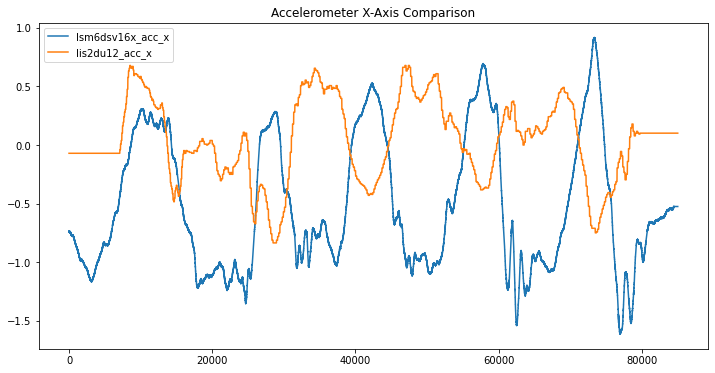

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import lightgbm as lgb
# import optuna

# from sklearn.model_selection import train_test_split, StratifiedKFold
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load and merge datasets
file_paths = {
    'walking': r"d:\Users\Ashmeet\Downloads\gesture4.csv",
}
dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label  # Assign activity label
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

print(data.columns)
# Check for missing values
data = data.dropna()
plt.figure(figsize=(12, 6))
plt.plot(data['lsm6dsv16x_acc_x [g]'], label='lsm6dsv16x_acc_x')
plt.plot(data['lis2du12_acc_x [g]'], label='lis2du12_acc_x')
plt.title('Accelerometer X-Axis Comparison')
plt.legend()
plt.show()

In [5]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
file_paths = {
    "g1": r"d:\Users\Ashmeet\Downloads\gesture1.csv",
    "g2": r"d:\Users\Ashmeet\Downloads\gesture2.csv",
    "g3": r"d:\Users\Ashmeet\Downloads\gesture3.csv",
    "g4": r"d:\Users\Ashmeet\Downloads\gesture4.csv"
}

dataframes = []
for label, path in file_paths.items():
    df = pd.read_csv(path)
    df['label'] = label
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

# Drop NaN values
data = data.dropna()

# Normalize the data
scaler = StandardScaler()
features = ['lsm6dsv16x_acc_x [g]', 'lsm6dsv16x_acc_y [g]', 'lsm6dsv16x_acc_z [g]',
            'lsm6dsv16x_gyro_x [dps]', 'lsm6dsv16x_gyro_y [dps]', 'lsm6dsv16x_gyro_z [dps]',
            'lis2du12_acc_x [g]', 'lis2du12_acc_y [g]', 'lis2du12_acc_z [g]',
            'lis2mdl_mag_x [G]', 'lis2mdl_mag_y [G]', 'lis2mdl_mag_z [G]',
            'lps22df_press [hPa]', 'stts22h_temp [°C]']

data[features] = scaler.fit_transform(data[features])

# Encode labels
data['label'] = data['label'].astype('category').cat.codes

# Split data into features and labels
X = data[features].values
y = data['label'].values

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape data for LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))

# Define the LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), verbose=2)

# Evaluate the model
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f'Validation Loss: {loss:.4f}')
print(f'Validation Accuracy: {accuracy:.4f}')


# Predict on new data
predictions = model.predict(X_val)
predictions = (predictions > 0.5).astype(int)

# Compare predictions with actual labels
for i in range(10):
    print(f'Predicted: {predictions[i]}, Actual: {y_val[i]}')

AttributeError: module 'numpy' has no attribute 'typeDict'

In [11]:
pip install numpy==1.19.5

  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 1.19.5 which is incompatible.
matplotlib 3.7.1 requires numpy>=1.20, but you have numpy 1.19.5 which is incompatible.
librosa 0.10.2.post1 requires numpy!=1.22.0,!=1.22.1,!=1.22.2,>=1.20.3, but you have numpy 1.19.5 which is incompatible.
